In [ ]:
import numpy as np
import pandas as pd

all_data = pd.read_parquet("all_features.parquet")
all_data.head(30)

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.00,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.00,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.00,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.00,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.00,2,12,40,0.598174,0.926941
5,SYNID0100001185,IND,NaN,0.009489,0.000000,1.145784,0.0,1.0,17.0,0.038706,...,0.604975,0,0,0,0.00,1,5,5,0.956522,0.956522
6,SYNID0100001300,IND,NaN,0.000000,7.333333,0.667736,1.0,0.0,18.0,2.544130,...,-0.697048,0,0,0,0.00,2,12,39,0.923077,0.989011
7,SYNID0100001310,IND,NaN,0.000000,0.000000,0.112450,0.0,0.0,18.0,0.035213,...,0.229794,0,0,0,0.00,1,4,4,1.000000,0.750000
8,SYNID0100001952,IND,NaN,0.000000,7.000000,NaN,0.0,0.0,18.0,NaN,...,0.264612,0,0,0,0.00,1,6,7,0.835821,1.000000
9,SYNID0100002045,IND,NaN,0.000000,0.000000,0.578450,1.0,0.0,18.0,0.369520,...,-0.347166,0,0,0,0.00,1,10,36,0.623932,0.991453


- Semi-supervised Self-Training Autoencoder (customer-level suspiciousness)

- Use label == 0 as seed “normal” customers.

- Train an autoencoder to reconstruct normal feature patterns.

- Score all customers by reconstruction error (higher = more anomalous).

- Self-training step (semi-supervised): from the unlabeled pool, add the lowest-error customers into the normal training set, retrain, and then score again.

- Output: a ranked list of customers with an anomaly score

In [28]:
all_data.info()
all_data["label"] = all_data["label"].astype("category")
all_data["is_retired"] = all_data["is_retired"].astype("category")
all_data["occupation_sector_id"] = all_data["occupation_sector_id"].astype("category")
all_data["is_unemployed"] = all_data["is_unemployed"].astype("category")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61410 entries, 0 to 61409
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   customer_id                   61410 non-null  object  
 1   customer_type                 61410 non-null  object  
 2   label                         1000 non-null   category
 3   cash_value_ratio              61410 non-null  float64 
 4   emt_velocity_monthly_mean     61410 non-null  float64 
 5   income_transaction_gap_score  38421 non-null  float64 
 6   is_retired                    53099 non-null  category
 7   is_unemployed                 53099 non-null  category
 8   occupation_sector_id          53099 non-null  category
 9   spending_income_ratio         38421 non-null  float64 
 10  rapid_outflow_ratio_24h       61410 non-null  float64 
 11  mean_debit                    58786 non-null  float64 
 12  median_debit                  58786 non-null  

In [29]:
# =========================================
# 0. Imports
# =========================================

import matplotlib.pyplot as plt
from requests import head
import seaborn as sns

from sklearn.model_selection import train_test_split    
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [30]:
# =========================================
# 1. Basic setup: split columns and define "seed normals"
# =========================================
df = all_data.copy()

ID_COLS = ["customer_id"]
LABEL_COL = "label"

# Keep label for splitting; drop ID from features
y = df[LABEL_COL]
X = df.drop(columns=ID_COLS + [LABEL_COL], errors="ignore")

# Seed normal set: confirmed normal customers
seed_normal_mask = (y == 0)

# Unlabeled pool (most of your data)
unlabeled_mask = y.isna()

print("Seed normals:", seed_normal_mask.sum())
print("Unlabeled:", unlabeled_mask.sum())
print("Total:", len(df))


Seed normals: 990
Unlabeled: 60410
Total: 61410


In [31]:
# =========================================
# 2. Preprocessing
# =========================================
# Identify categorical vs numeric columns
cat_cols = [c for c in X.columns if str(X[c].dtype) in ["object", "category"]]
forced_cat = ["occupation_sector_id"]
cat_cols = sorted(set(cat_cols + [c for c in forced_cat if c in X.columns]))
num_cols = [c for c in X.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler(with_centering=True)) # RobustScaler is safer for heavy-tailed AML features like ratios, counts, gaps
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

# Fit preprocess ONLY on seed normals to avoid leaking anomaly patterns into scaling
X_seed = X.loc[seed_normal_mask]
preprocess.fit(X_seed)

X_seed_t = preprocess.transform(X_seed)
X_all_t  = preprocess.transform(X)

print("Transformed shape:", X_all_t.shape)


Transformed shape: (61410, 73)


c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\32451\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['kurt_debit' 'kurt_credit']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [54]:
# =========================================
# 3. Define a small Autoencoder (dense, tabular)
# =========================================
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, bottleneck_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, bottleneck_dim),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

def train_ae(X_train_np, epochs=75, batch_size=512, lr=1e-3, weight_decay=1e-5, verbose=True):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    X_train = torch.tensor(X_train_np, dtype=torch.float32)
    loader = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True, drop_last=False)

    model = AutoEncoder(input_dim=X_train_np.shape[1]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss(reduction="mean")

    model.train()
    for ep in range(1, epochs + 1):
        losses = []
        for (xb,) in loader:
            xb = xb.to(device)
            opt.zero_grad()
            recon = model(xb)
            loss = loss_fn(recon, xb)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        if verbose and (ep % 5 == 0 or ep == 1):
            print(f"Epoch {ep:02d} | loss={np.mean(losses):.6f}")
    return model

@torch.no_grad()
def reconstruction_error(model, X_np):
    device = next(model.parameters()).device
    X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
    model.eval()
    recon = model(X_t)
    # per-row mean squared error
    mse = torch.mean((recon - X_t) ** 2, dim=1).detach().cpu().numpy()
    return mse


In [55]:
# =========================================
# 4. Semi-supervised self-training loop
#    (expand normal set using low-error unlabeled points)
# =========================================
X_seed_np = X_seed_t.astype(np.float32)
X_tr, X_va = train_test_split(X_seed_np, test_size=0.3, random_state=RANDOM_SEED)
X_unlab_np = X_all_t[unlabeled_mask.values].astype(np.float32)

# Step A: train on seed normals
ae0 = train_ae(X_tr, epochs=75, lr=3e-4, weight_decay=1e-4, verbose=True)

# Step B: score unlabeled; add "most normal" from unlabeled into normal training
unlab_scores0 = reconstruction_error(ae0, X_unlab_np)

# Heuristic: take the 10% of unlabeled with lowest reconstruction error as "likely normal"
q = 0.3   # 10% most-normal unlabeled
threshold_q = np.quantile(unlab_scores0, q)
likely_normal_unlab = X_unlab_np[unlab_scores0 <= threshold_q]

print("Likely-normal unlabeled added:", likely_normal_unlab.shape[0])

# Also exclude very high-error unlabeled from future training which avoids contaminating normal set
# high_cut = np.quantile(unlab_scores0, 0.98)   # top 2% anomalies
# mask_keep = unlab_scores0 <= high_cut
# X_unlab_clean = X_unlab_np[mask_keep]
# Step C: retrain AE on expanded normal data
X_expanded = np.vstack([X_seed_np, likely_normal_unlab])
ae1 = train_ae(X_expanded, lr=3e-4, weight_decay=1e-4, epochs=75, verbose=True)

# Final scoring for ALL customers
all_scores = reconstruction_error(ae1, X_all_t.astype(np.float32))

df_scores = df[["customer_id", "customer_type"]].copy()
df_scores["anomaly_score"] = all_scores

df_scores.sort_values("anomaly_score", ascending=False).head(10)


Epoch 01 | loss=140686.519531
Epoch 05 | loss=157555.570312
Epoch 10 | loss=218444.718750
Epoch 15 | loss=151175.746094
Epoch 20 | loss=168747.335938
Epoch 25 | loss=149522.093750
Epoch 30 | loss=152822.562500
Epoch 35 | loss=114346.179688
Epoch 40 | loss=105046.140625
Epoch 45 | loss=71887.677734
Epoch 50 | loss=102593.255859
Epoch 55 | loss=52290.245117
Epoch 60 | loss=50825.050781
Epoch 65 | loss=38781.335938
Epoch 70 | loss=51844.144531
Epoch 75 | loss=48777.663086
Likely-normal unlabeled added: 18123
Epoch 01 | loss=13658.096288
Epoch 05 | loss=7761.604203
Epoch 10 | loss=1265.713447
Epoch 15 | loss=138.831004
Epoch 20 | loss=42.635278
Epoch 25 | loss=41.684903
Epoch 30 | loss=28.504309
Epoch 35 | loss=52.377735
Epoch 40 | loss=40.016383
Epoch 45 | loss=12.150175
Epoch 50 | loss=10.030927
Epoch 55 | loss=22.983901
Epoch 60 | loss=66.737794
Epoch 65 | loss=7.973693
Epoch 70 | loss=59.638390
Epoch 75 | loss=6.640895


,customer_id,customer_type,anomaly_score
1766,SYNID0100340845,IND,483124992.0
20642,SYNID0103893826,IND,179344768.0
32431,SYNID0106084824,IND,171686528.0
22775,SYNID0104304053,IND,85658008.0
18582,SYNID0103498635,IND,67932568.0
45578,SYNID0108548082,IND,63251008.0
3498,SYNID0100662953,IND,52846480.0
46523,SYNID0108730304,IND,46089976.0
34472,SYNID0106479004,IND,45836248.0
24599,SYNID0104632267,IND,36910612.0


In [56]:
# =========================================
# 5. Turn anomaly scores into alerts
# =========================================
# Alert top p% highest scores

# p = 0.01  # 1% alerts (adjust this threshold based on your investigation capacity)
# alert_cut = np.quantile(df_scores["anomaly_score"], 1 - p)

# df_scores["is_alert"] = (df_scores["anomaly_score"] >= 4.61).astype(int) # tuned threshold >= 4.61

# labeled subset
labeled_mask = df[LABEL_COL].notna()
y_true = df.loc[labeled_mask, LABEL_COL].astype(int).values
scores_labeled = df_scores.loc[labeled_mask, "anomaly_score"].values

precision, recall, thresholds = precision_recall_curve(y_true, scores_labeled)

# F1 for each threshold point (thresholds length = len(precision)-1)
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best-F1 threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

# apply to ALL customers
df_scores["predicted_label"] = (df_scores["anomaly_score"] >= best_threshold).astype(int)

# risk_score: higher anomaly_score => higher risk_score, scaled to [0,1]
df_scores["risk_score"] = df_scores["anomaly_score"].rank(method="average", pct=True).astype(float)



Best-F1 threshold: 4333.753
Precision: 0.2222222222222222
Recall: 0.4
F1: 0.28571428571382657


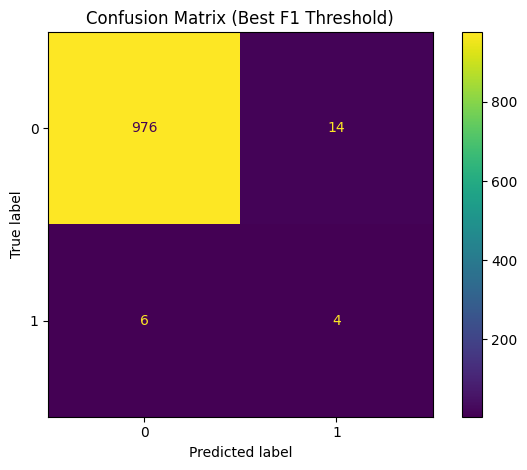

TP: 4
FP: 14
FN: 6
TN: 976
Precision: 0.2222222222222099
Recall: 0.39999999999996
F1: 0.2857142857138062


In [57]:
# =========================================
# 6. Confusion matrix on labeled data
# =========================================
y_true = df.loc[labeled_mask, LABEL_COL].astype(int).values
y_pred = df_scores.loc[labeled_mask, "predicted_label"].astype(int).values

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()

plt.title("Confusion Matrix (Best F1 Threshold)")
plt.tight_layout()
plt.show()

# Optional: print metrics
tn, fp, fn, tp = cm.ravel()

precision_val = tp / (tp + fp + 1e-12)
recall_val = tp / (tp + fn + 1e-12)
f1_val = 2 * precision_val * recall_val / (precision_val + recall_val + 1e-12)

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)
print("Precision:", precision_val)
print("Recall:", recall_val)
print("F1:", f1_val)

In [58]:
# using AUC

auc = roc_auc_score(y_true, scores_labeled)
print("AUC:", auc)

AUC: 0.8092929292929293


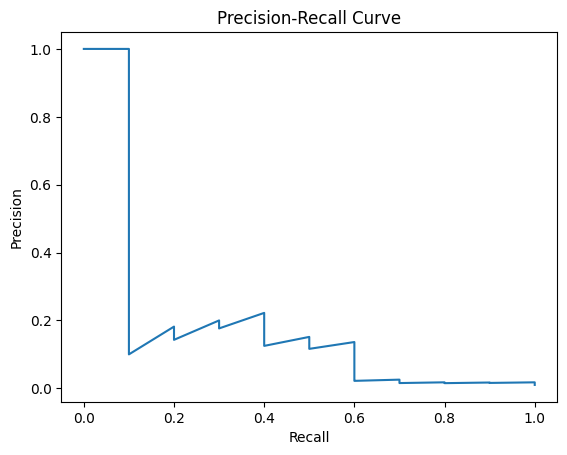

In [59]:

# scores_labeled = df_scores.loc[labeled_mask, "anomaly_score"]
# y_true = df.loc[labeled_mask, LABEL_COL].astype(int)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [ ]:
# choose threshold that gives ~70% recall
# threshold = np.percentile(scores_labeled, 70)
# df_scores["is_alert"] = (df_scores["anomaly_score"] >= threshold).astype(int)
# threshold

NameError: name 'np' is not defined

In [60]:
# with Isolation Forest ensemble the risk score by combining AE anomaly score with Isolation Forest anomaly score (normalized and weighted)
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler


# 1) Fit Isolation Forest on transformed features (all customers)
iso = IsolationForest(
    n_estimators=500,
    contamination="auto",   # don't force a rate yet; we'll threshold using labels
    random_state=RANDOM_SEED,
    n_jobs=-1
)
iso.fit(X_all_t)

# IsolationForest: higher = more anomalous (use negative decision_function)
iso_score = -iso.decision_function(X_all_t)

# 2) Normalize both scores to [0,1] for a fair ensemble
mm = MinMaxScaler()
ae_norm  = mm.fit_transform(df_scores[["anomaly_score"]].values).ravel()

mm2 = MinMaxScaler()
iso_norm = mm2.fit_transform(iso_score.reshape(-1, 1)).ravel()

# 3) Ensemble risk score (start with equal weights)
w_ae = 0.5
w_iso = 0.5
df_scores["risk_score"] = (w_ae * ae_norm + w_iso * iso_norm).clip(0, 1)

df_scores[["customer_id", "anomaly_score", "risk_score"]].head()

,customer_id,anomaly_score,risk_score
0,SYNID0100000167,0.120653,0.073971
1,SYNID0100000431,0.758989,0.029179
2,SYNID0100000485,0.251254,0.043808
3,SYNID0100000539,62.598125,0.095856
4,SYNID0100000932,49.884720,0.156710


Best-F1 threshold: 0.19968961864207624
Precision: 0.2
Recall: 0.2
F1: 0.19999999999950005
Total alerts: 2036


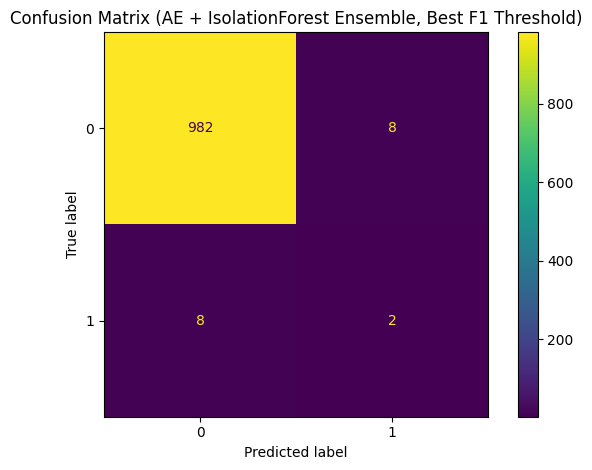

TN, FP, FN, TP = 982 8 8 2


In [61]:
labeled_mask = df[LABEL_COL].notna()
y_true = df.loc[labeled_mask, LABEL_COL].astype(int).values
scores_labeled = df_scores.loc[labeled_mask, "risk_score"].values

precision, recall, thresholds = precision_recall_curve(y_true, scores_labeled)

# Align arrays: thresholds length = len(precision)-1
f1 = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]

print("Best-F1 threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

# Apply to all customers
df_scores["predicted_label"] = (df_scores["risk_score"] >= best_threshold).astype(int)
print("Total alerts:", df_scores["predicted_label"].sum())

y_pred = df_scores.loc[labeled_mask, "predicted_label"].astype(int).values
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title("Confusion Matrix (AE + IsolationForest Ensemble, Best F1 Threshold)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN, FP, FN, TP =", tn, fp, fn, tp)